[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


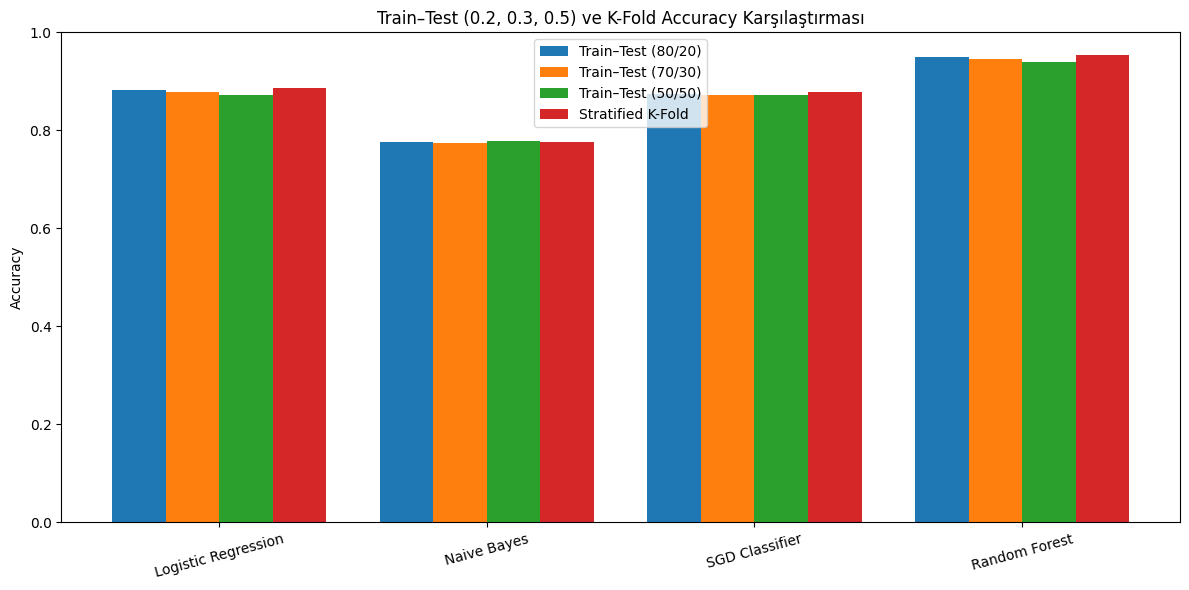

In [ ]:
# ==============================
# 1️⃣ KÜTÜPHANELER
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

nltk.download("stopwords")

# ==============================
# 2️⃣ VERİ YÜKLEME & LABEL 70.000 satırlık Türkçe haber veri seti okunur Bozuk satırlar atlanır Başlık + haber metni birleştirilir Küçük harfe çevrilir (normalizasyon)
# ==============================
df = pd.read_csv(
    "/content/turkish_news_70000.csv",
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8"
)

df["content"] = (
    df["title"].fillna("") + " " + df["text"].fillna("")
).str.lower()
#Anahtar Kelime Tabanlı Yarı-Denetimli Etiketleme Fake ve gerçek haberlerde sık geçen anahtar kelimeler tanımlanır Metin içinde anahtar kelime sayımı yapılır Fake > Real → 1 (sahte) Real > Fake → 0 (gerçek)Belirsiz → None
fake_keywords = [
    "iddia edildi", "şok", "bomba", "inanılmaz", "doğru mu", "yalan",
    "ortaya çıktı", "sosyal medyada", "komplo", "asılsız", "iddiası"
]

real_keywords = [
    "açıklama yaptı", "resmi", "rapor", "verilere göre",
    "yetkililer", "basın açıklaması"
]

def label_from_text(text):
    fake = sum(1 for k in fake_keywords if k in text)
    real = sum(1 for k in real_keywords if k in text)
    if fake > real and fake >= 1:
        return 1
    elif real > fake and real >= 1:
        return 0
    else:
        return None

df["label"] = df["content"].apply(label_from_text)
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

X = df["content"]
y = df["label"]

# ==============================
# 3️⃣ TF-IDF En fazla 3000 kelime Türkçe stop-word’ler çıkarılır
# ==============================
tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words=stopwords.words("turkish")
)
#Metinler sayısal vektöre dönüştürülür
X_tfidf = tfidf.fit_transform(X)

# ==============================
# 4️⃣ MODELLER
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SGD Classifier": SGDClassifier(loss="log_loss", max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# ==============================
# 5️⃣ TRAIN–TEST (0.2, 0.3, 0.5)
# ==============================
test_sizes = [0.2, 0.3, 0.5]
train_test_results = []

for test_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        train_test_results.append({
            "Model": name,
            "Test Size": test_size,
            "Accuracy": accuracy_score(y_test, y_pred)
        })

train_test_df = pd.DataFrame(train_test_results)

# ==============================
# 6️⃣ STRATIFIED K-FOLD
# ==============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kfold_results = []

for name, model in models.items():
    acc = []
    for train_idx, test_idx in cv.split(X_tfidf, y):
        X_tr, X_te = X_tfidf[train_idx], X_tfidf[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_tr, y_tr)
        acc.append(accuracy_score(y_te, model.predict(X_te)))

    kfold_results.append({
        "Model": name,
        "Accuracy": np.mean(acc)
    })

kfold_df = pd.DataFrame(kfold_results)

# ==============================
# 7️⃣ BİRLEŞİK ACCURACY GRAFİĞİ
# ==============================
models_list = list(models.keys())
x = np.arange(len(models_list))
width = 0.2

plt.figure(figsize=(12,6))

for i, ts in enumerate(test_sizes):
    acc_vals = train_test_df[train_test_df["Test Size"] == ts]["Accuracy"]
    plt.bar(
        x + (i-1)*width,
        acc_vals,
        width,
        label=f"Train–Test ({int((1-ts)*100)}/{int(ts*100)})"
    )

# K-Fold barı
plt.bar(
    x + 2*width,
    kfold_df["Accuracy"],
    width,
    label="Stratified K-Fold"
)

plt.xticks(x + width/2, models_list, rotation=15)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Train–Test (0.2, 0.3, 0.5) ve K-Fold Accuracy Karşılaştırması")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kfold_results = []

for name, model in models.items():
    acc, prec, rec, f1 = [], [], [], []

    for train_idx, test_idx in cv.split(X_tfidf, y):
        X_tr, X_te = X_tfidf[train_idx], X_tfidf[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        acc.append(accuracy_score(y_te, y_pred))
        prec.append(precision_score(y_te, y_pred))
        rec.append(recall_score(y_te, y_pred))
        f1.append(f1_score(y_te, y_pred))

    kfold_results.append({
        "Model": name,
        "Evaluation": "Stratified K-Fold (k=5)",
        "Accuracy": np.mean(acc),
        "Precision": np.mean(prec),
        "Recall": np.mean(rec),
        "F1-score": np.mean(f1)
    })

kfold_df = pd.DataFrame(kfold_results)
print("\nK-FOLD PERFORMANS METRİKLERİ\n")
print(kfold_df)



K-FOLD PERFORMANS METRİKLERİ

                 Model               Evaluation  Accuracy  Precision  \
0  Logistic Regression  Stratified K-Fold (k=5)  0.887263   0.888743   
1          Naive Bayes  Stratified K-Fold (k=5)  0.777045   0.902999   
2       SGD Classifier  Stratified K-Fold (k=5)  0.878632   0.878896   
3        Random Forest  Stratified K-Fold (k=5)  0.953147   0.947019   

     Recall  F1-score  
0  0.917012  0.902621  
1  0.682064  0.776970  
2  0.912872  0.895521  
3  0.972149  0.959411  


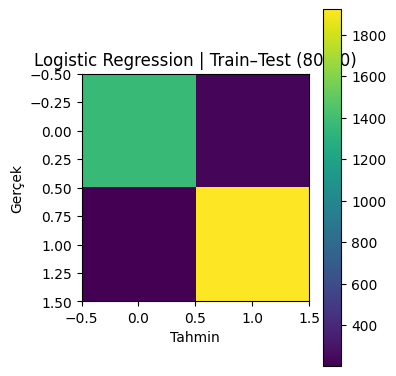

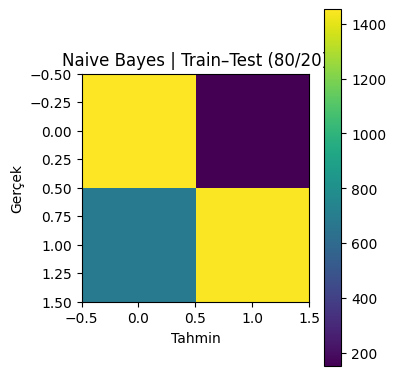

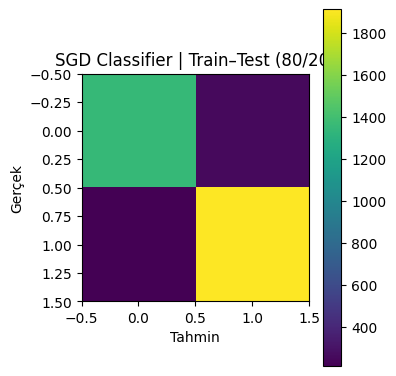

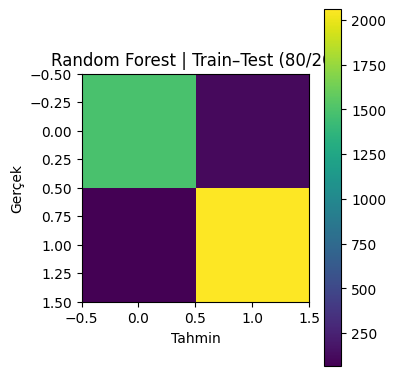

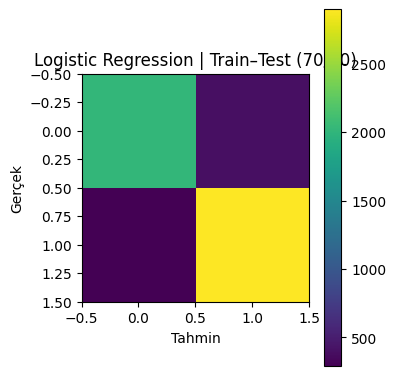

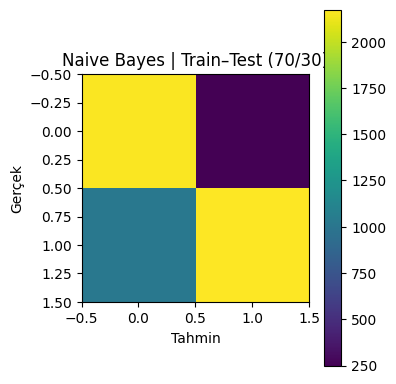

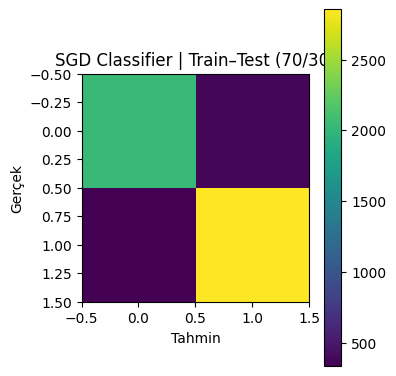

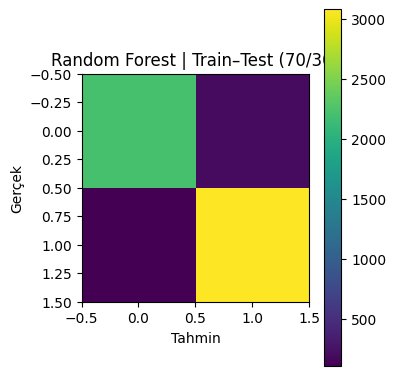

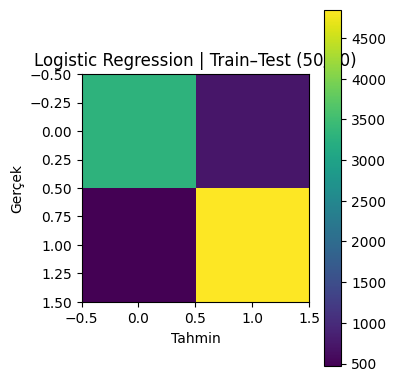

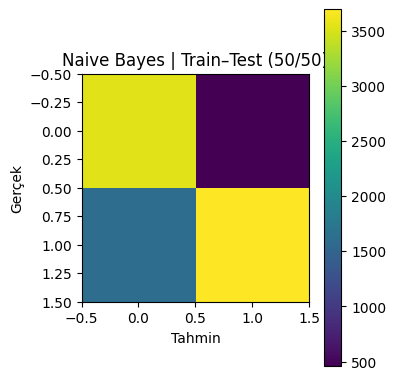

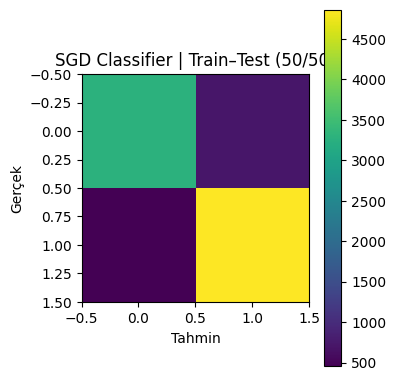

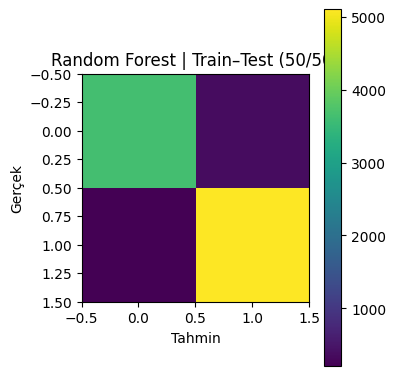


TRAIN–TEST PERFORMANS TABLOSU


,Model,Test Size,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.2,0.883141,0.891929,0.904516,0.898178
1,Naive Bayes,0.2,0.776199,0.904702,0.678739,0.775598
2,SGD Classifier,0.2,0.875101,0.882841,0.900282,0.891476
3,Random Forest,0.2,0.950147,0.944954,0.968956,0.956804
4,Logistic Regression,0.3,0.877970,0.880620,0.909062,0.894615
5,Naive Bayes,0.3,0.774701,0.898677,0.681405,0.775103
6,SGD Classifier,0.3,0.872432,0.882535,0.895265,0.888854
7,Random Forest,0.3,0.945328,0.939884,0.965820,0.952676
8,Logistic Regression,0.5,0.872735,0.870400,0.912495,0.890951
9,Naive Bayes,0.5,0.777528,0.889771,0.695709,0.780864



STRATIFIED K-FOLD PERFORMANS TABLOSU


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.887263,0.888743,0.917012,0.902621
1,Naive Bayes,0.777045,0.902999,0.682064,0.776970
2,SGD Classifier,0.877506,0.876016,0.914566,0.894829
3,Random Forest,0.953147,0.947019,0.972149,0.959411


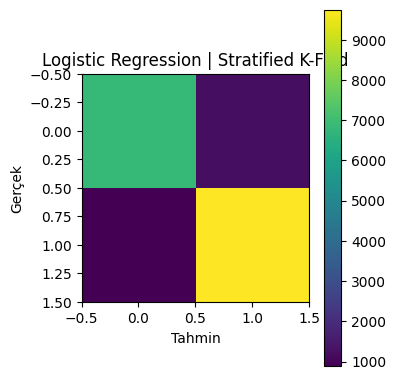

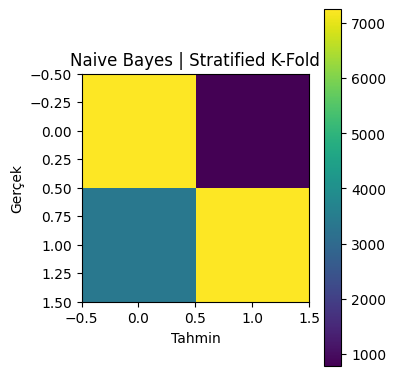

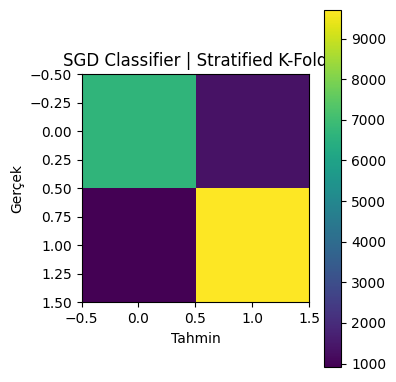

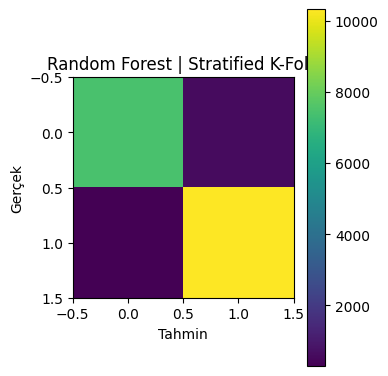

In [ ]:
# =========================================================
# 8️⃣ TRAIN–TEST: Accuracy, Precision, Recall, F1 + CM
# =========================================================
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_predict

train_test_metrics = []

for test_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        train_test_metrics.append({
            "Model": name,
            "Test Size": test_size,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred)
        })

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4,4))
        plt.imshow(cm)
        plt.title(f"{name} | Train–Test ({int((1-test_size)*100)}/{int(test_size*100)})")
        plt.xlabel("Tahmin")
        plt.ylabel("Gerçek")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

train_test_metrics_df = pd.DataFrame(train_test_metrics)
print("\nTRAIN–TEST PERFORMANS TABLOSU")
display(train_test_metrics_df)


# =========================================================
# 9️⃣ STRATIFIED K-FOLD: Accuracy, Precision, Recall, F1
# =========================================================
kfold_metrics = []

for name, model in models.items():
    acc, prec, rec, f1 = [], [], [], []

    for train_idx, test_idx in cv.split(X_tfidf, y):
        X_tr, X_te = X_tfidf[train_idx], X_tfidf[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        acc.append(accuracy_score(y_te, y_pred))
        prec.append(precision_score(y_te, y_pred))
        rec.append(recall_score(y_te, y_pred))
        f1.append(f1_score(y_te, y_pred))

    kfold_metrics.append({
        "Model": name,
        "Accuracy": np.mean(acc),
        "Precision": np.mean(prec),
        "Recall": np.mean(rec),
        "F1-Score": np.mean(f1)
    })

kfold_metrics_df = pd.DataFrame(kfold_metrics)
print("\nSTRATIFIED K-FOLD PERFORMANS TABLOSU")
display(kfold_metrics_df)


# =========================================================
# 🔟 STRATIFIED K-FOLD CONFUSION MATRIX
# =========================================================
for name, model in models.items():
    y_pred_cv = cross_val_predict(model, X_tfidf, y, cv=cv)
    cm = confusion_matrix(y, y_pred_cv)

    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(f"{name} | Stratified K-Fold")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


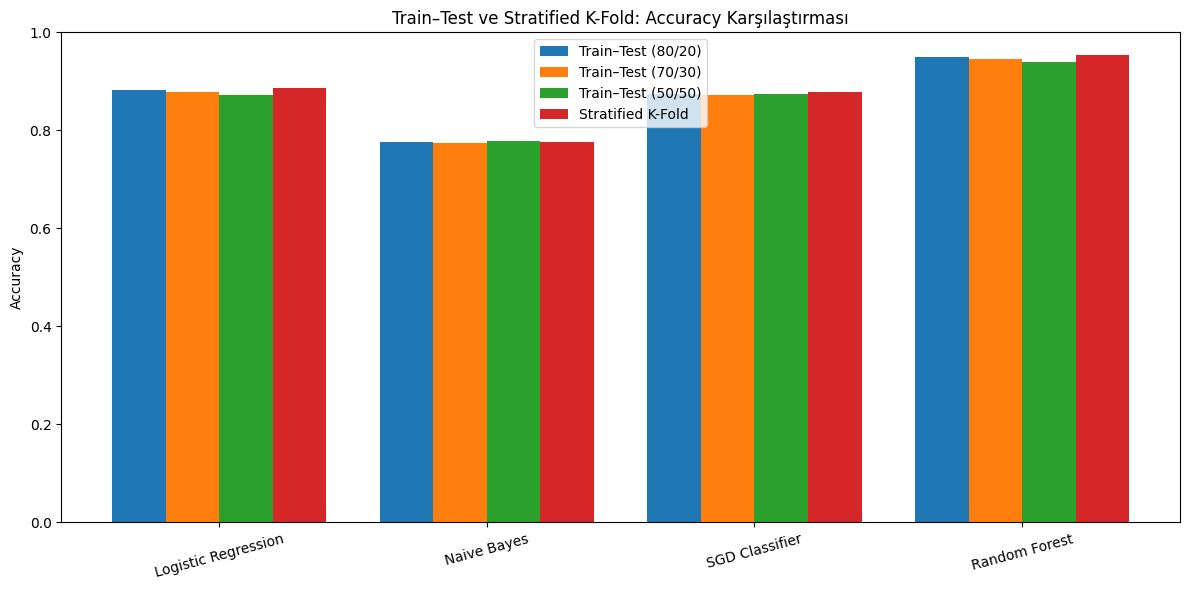

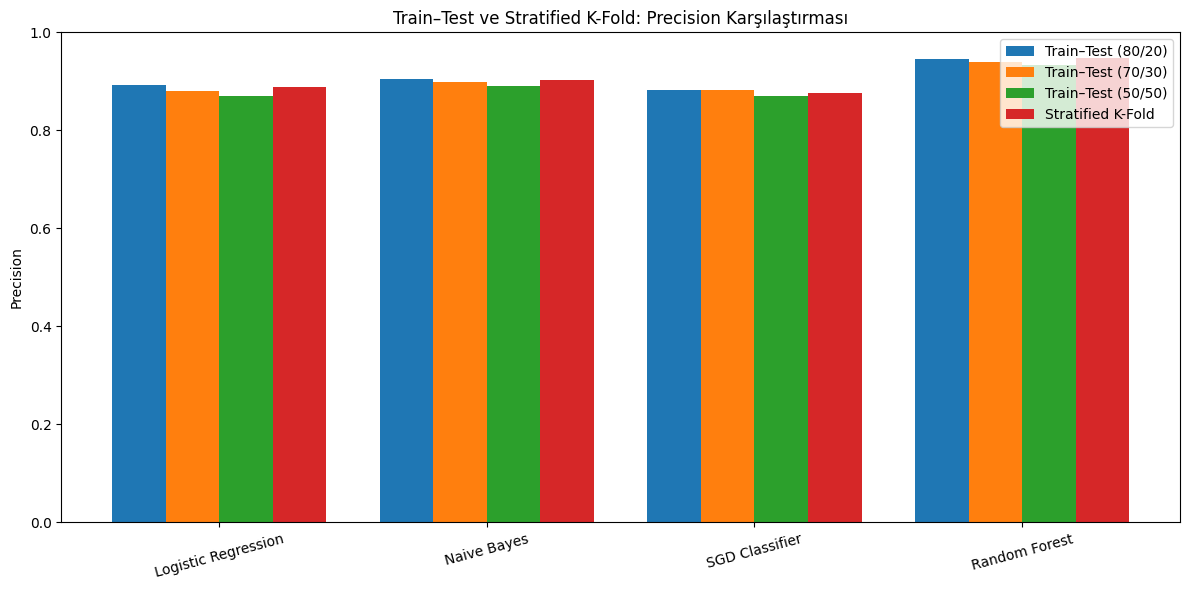

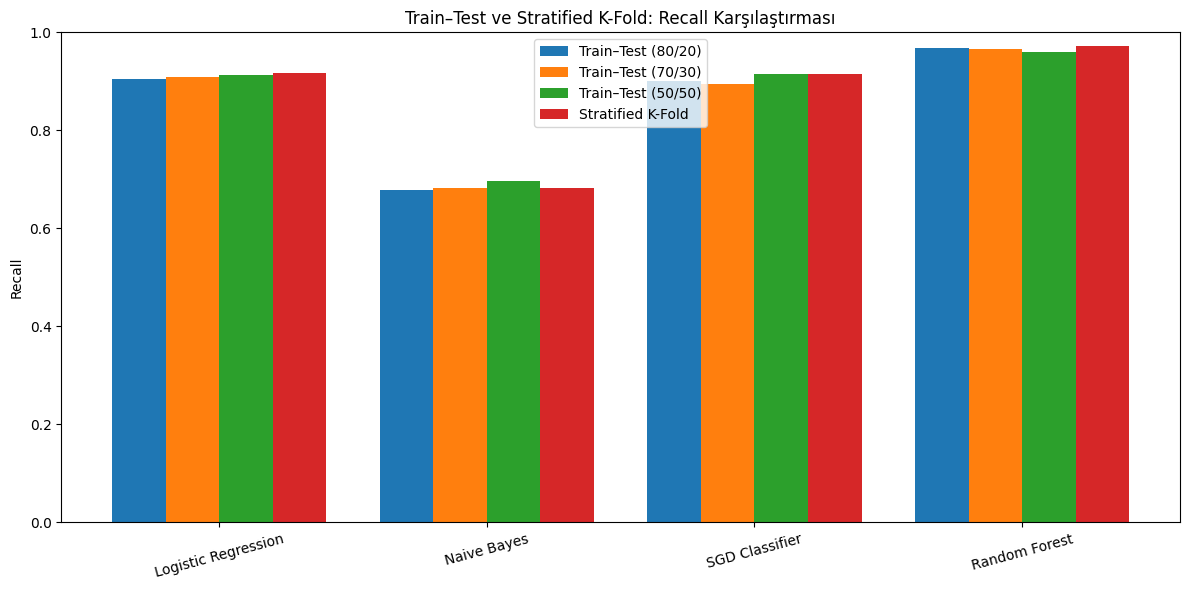

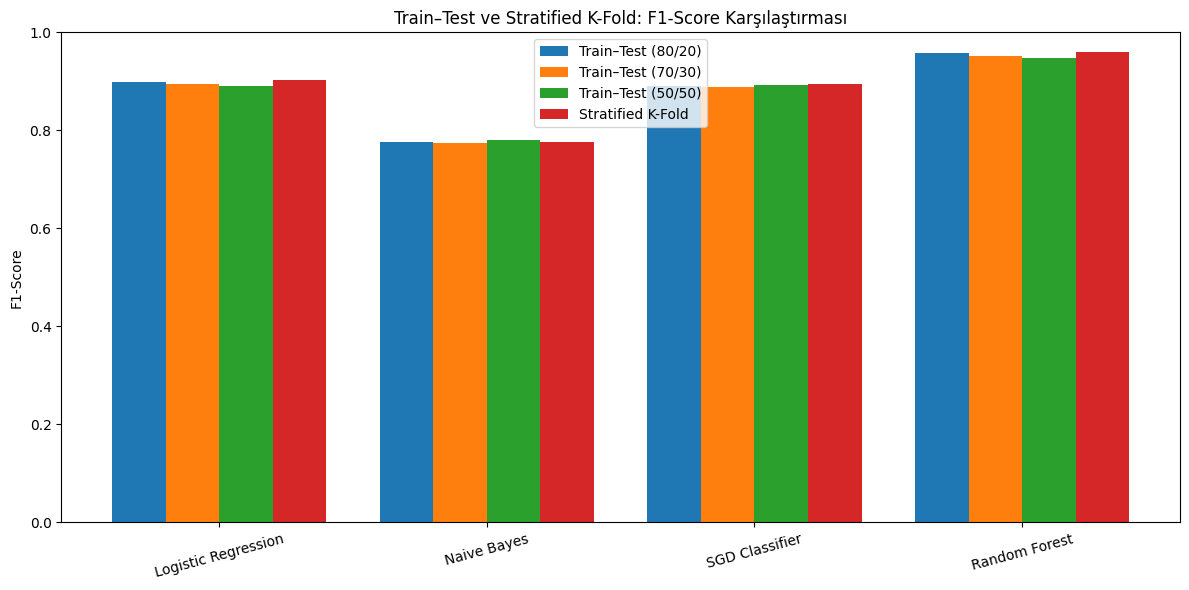

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

# Train–Test için renk paleti
colors_tt = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # test_size=0.2,0.3,0.5
test_labels = [f"Train–Test ({int((1-ts)*100)}/{int(ts*100)})" for ts in test_sizes]

# -------------------------------
# 1️⃣ TRAIN–TEST + K-FOLD BİRLEŞİK GRAFİK
# -------------------------------
for metric in metrics:
    plt.figure(figsize=(12,6))
    x = np.arange(len(models))  # model sayısı
    width = 0.2

    # Train–Test barları
    for i, ts in enumerate(test_sizes):
        subset = train_test_metrics_df[train_test_metrics_df["Test Size"] == ts]
        plt.bar(
            x + (i-1)*width,
            subset[metric],
            width=width,
            color=colors_tt[i],
            label=test_labels[i]
        )

    # K-Fold barı
    plt.bar(
        x + 2*width,
        kfold_metrics_df[metric],
        width=width,
        color="#d62728",
        label="Stratified K-Fold"
    )

    plt.xticks(x + width/2, list(models.keys()), rotation=15)
    plt.ylim(0,1)
    plt.ylabel(metric)
    plt.title(f"Train–Test ve Stratified K-Fold: {metric} Karşılaştırması")
    plt.legend()
    plt.tight_layout()
    plt.show()


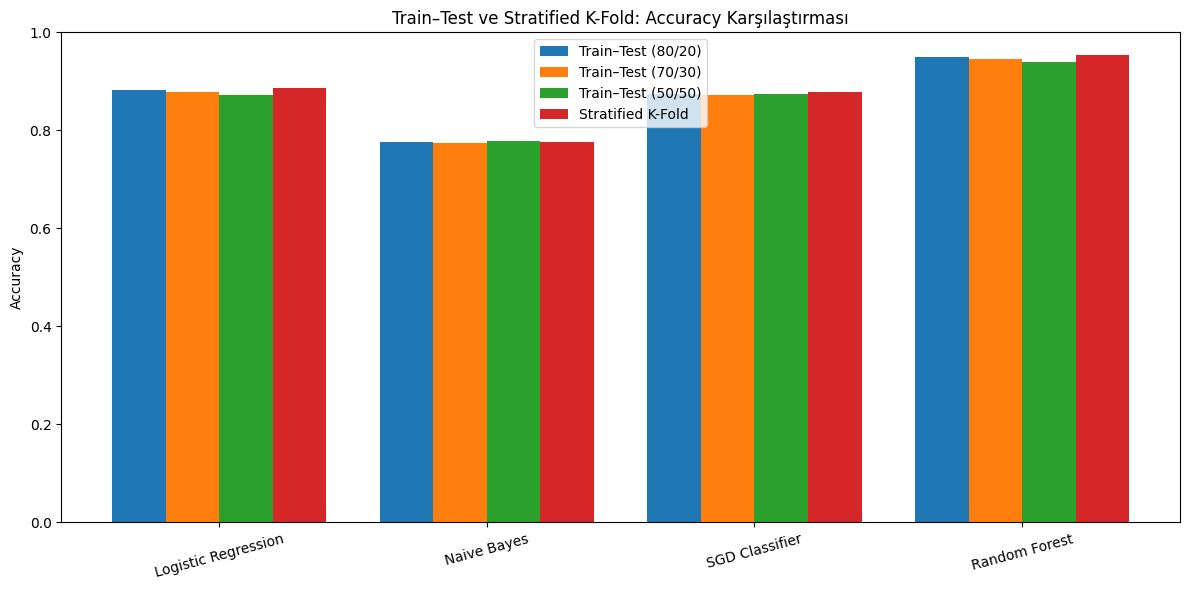

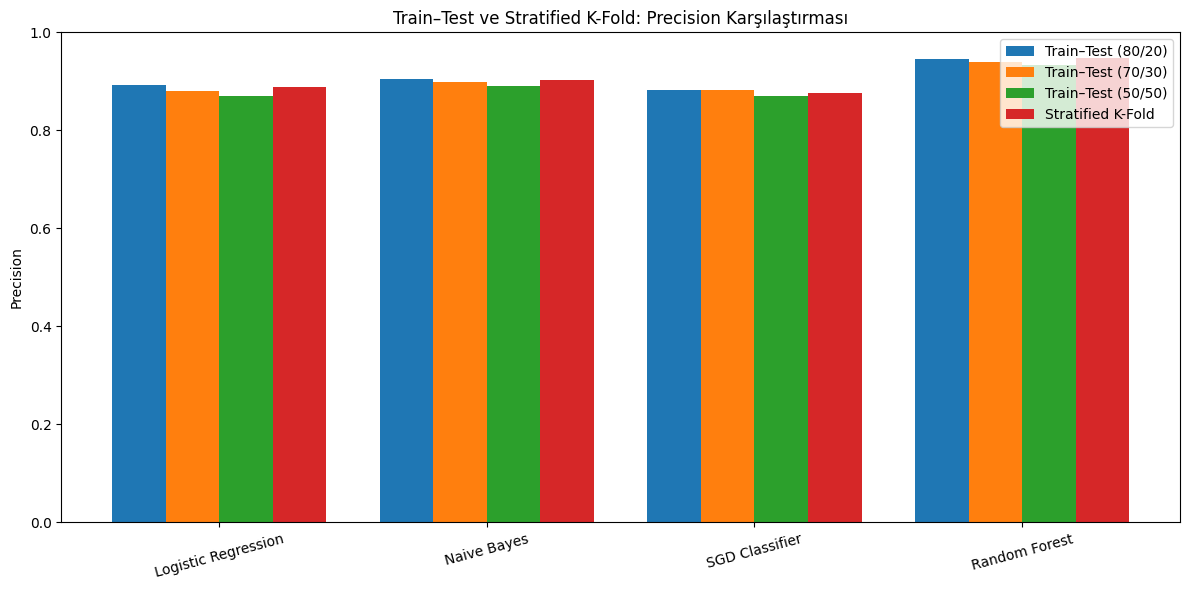

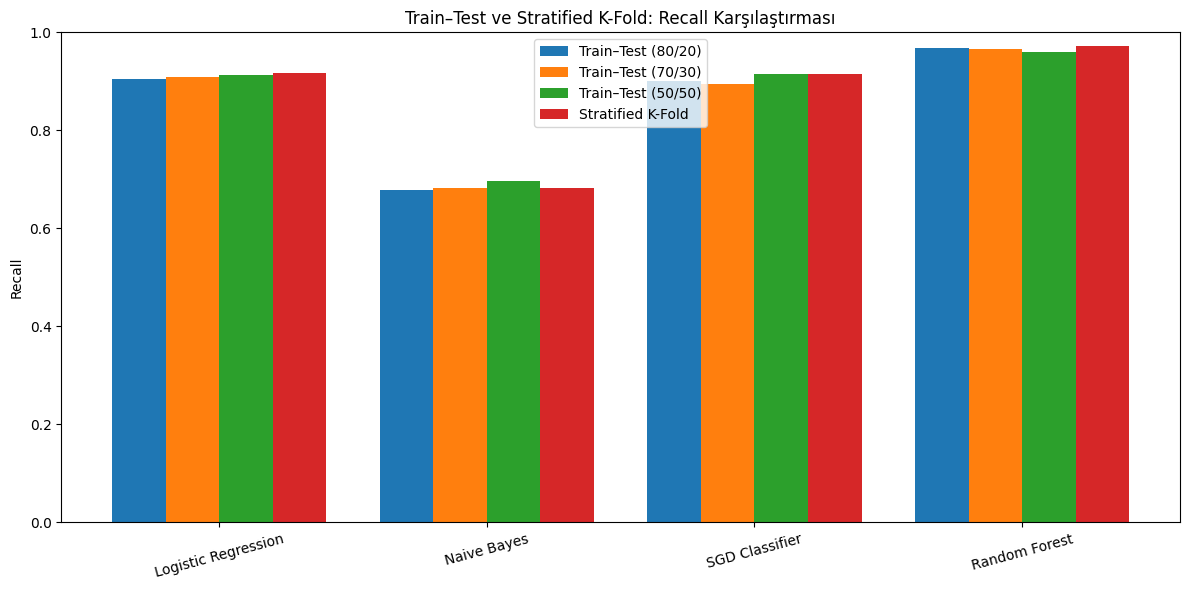

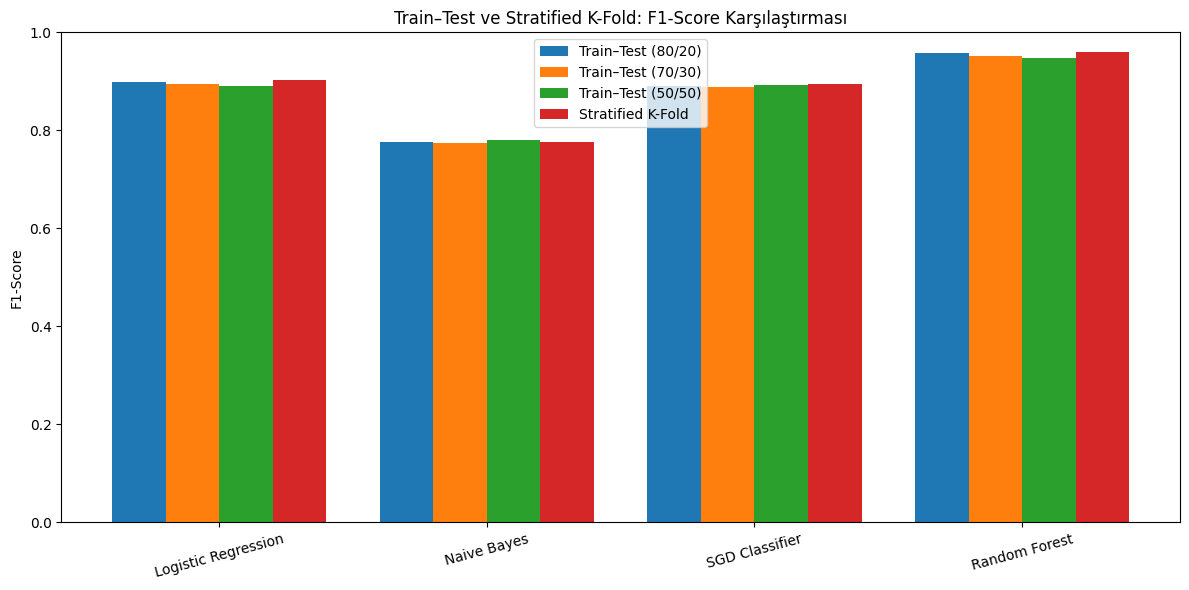

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

colors_tt = ["#1f77b4", "#ff7f0e", "#2ca02c"]
test_labels = [f"Train–Test ({int((1-ts)*100)}/{int(ts*100)})" for ts in test_sizes]

# -------------------------------
# 1️⃣ GÜVENLI BİRLEŞİK GRAFİK
# -------------------------------
for metric in metrics:
    plt.figure(figsize=(12,6))
    x = np.arange(len(models))  # model sayısı
    width = 0.2

    # Train–Test barları
    for i, ts in enumerate(test_sizes):
        subset = train_test_metrics_df[train_test_metrics_df["Test Size"] == ts].copy()
        # Undefined metrikleri 0 ile doldur
        subset[metric] = subset[metric].fillna(0)
        plt.bar(
            x + (i-1)*width,
            subset[metric],
            width=width,
            color=colors_tt[i],
            label=test_labels[i]
        )

    # K-Fold barı
    kfold_subset = kfold_metrics_df.copy()
    kfold_subset[metric] = kfold_subset[metric].fillna(0)
    plt.bar(
        x + 2*width,
        kfold_subset[metric],
        width=width,
        color="#d62728",
        label="Stratified K-Fold"
    )

    plt.xticks(x + width/2, list(models.keys()), rotation=15)
    plt.ylim(0,1)
    plt.ylabel(metric)
    plt.title(f"Train–Test ve Stratified K-Fold: {metric} Karşılaştırması")
    plt.legend()
    plt.tight_layout()
    plt.show()


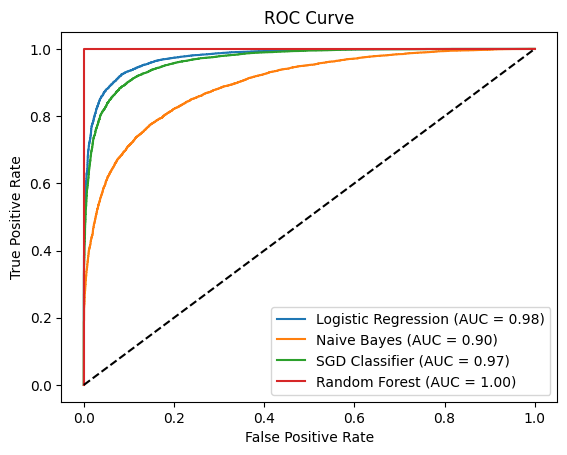

In [ ]:
from sklearn.metrics import roc_curve, auc

for name, model in models.items():
    y_pred_prob = model.fit(X_tfidf, y).predict_proba(X_tfidf)[:,1]
    fpr, tpr, _ = roc_curve(y, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


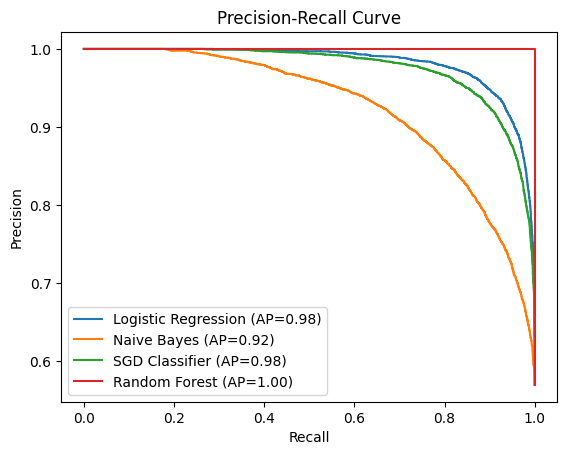

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

for name, model in models.items():
    y_pred_prob = model.fit(X_tfidf, y).predict_proba(X_tfidf)[:,1]
    precision, recall, _ = precision_recall_curve(y, y_pred_prob)
    ap = average_precision_score(y, y_pred_prob)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


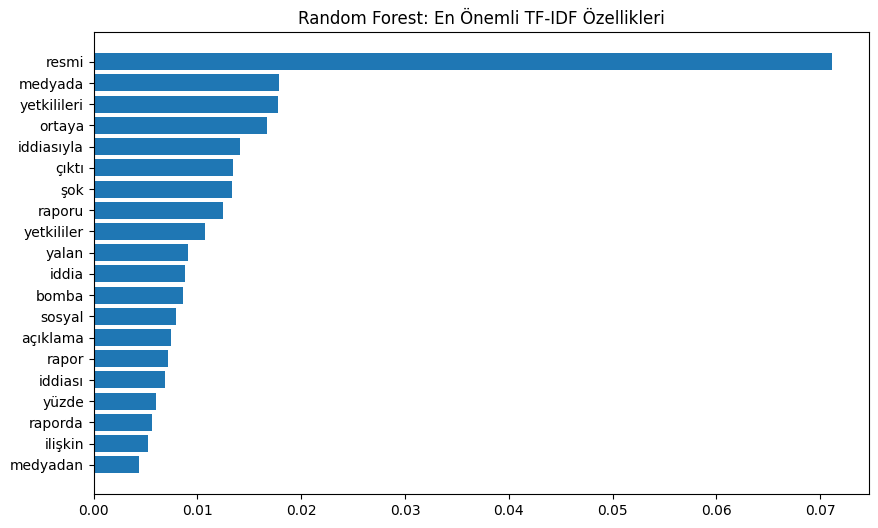

In [ ]:
importances = models["Random Forest"].feature_importances_
indices = np.argsort(importances)[-20:]  # en önemli 20
features = tfidf.get_feature_names_out()
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Random Forest: En Önemli TF-IDF Özellikleri")
plt.show()
